In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# IMPORT Y CARGA DE DATOS
df = pd.read_csv("../data/processed/huelva_weather_clean.csv", parse_dates=["date"])
monthly = pd.read_csv("../data/processed/huelva_monthly.csv")
seasonal = pd.read_csv("../data/processed/huelva_seasonal.csv")

df.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,sunshine_hours,year,month,day,month_name,weekday,season,temp_range,rain_category
0,2020-01-01,16.6,5.2,9.9,0.0,11.1,9.00,2020,1,1,January,2,Invierno,11.4,Sin lluvia
1,2020-01-02,15.1,4.7,9.9,0.0,10.0,8.96,2020,1,2,January,3,Invierno,10.4,Sin lluvia
2,2020-01-03,16.4,9.9,12.1,0.0,10.4,6.32,2020,1,3,January,4,Invierno,6.5,Sin lluvia
3,2020-01-04,15.1,5.2,9.5,0.0,9.7,9.00,2020,1,4,January,5,Invierno,9.9,Sin lluvia
4,2020-01-05,16.7,7.8,11.2,0.0,14.5,9.00,2020,1,5,January,6,Invierno,8.9,Sin lluvia


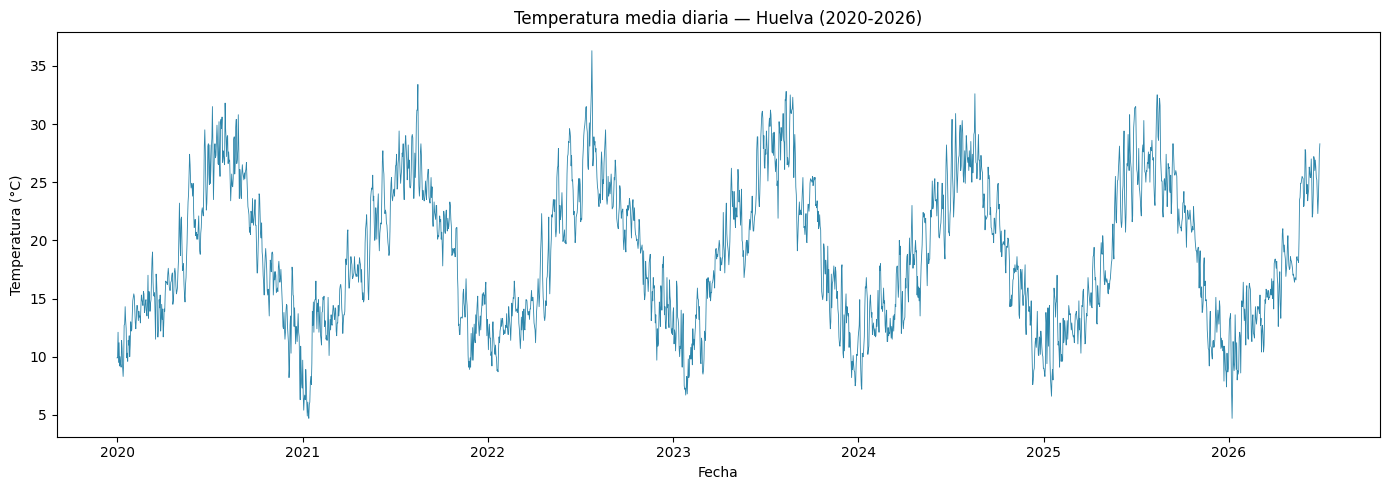

In [2]:
#  Evolución de temperatura media a lo largo del tiempo
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["temperature_2m_mean"], linewidth=0.6, color="#2E86AB")
ax.set_title("Temperatura media diaria — Huelva (2020-2026)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

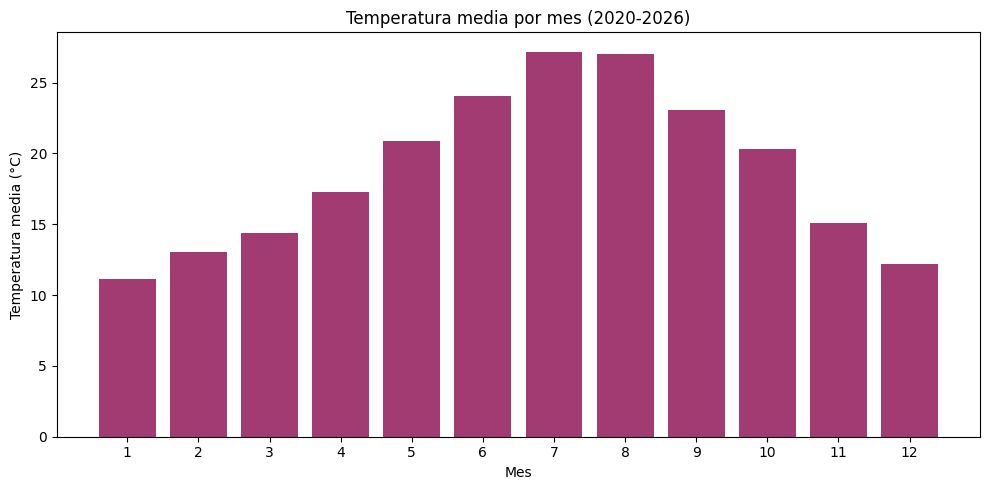

In [3]:
# Temperatura media por mes (todos los años juntos)
fig, ax = plt.subplots(figsize=(10, 5))
monthly_avg = df.groupby("month")["temperature_2m_mean"].mean()
ax.bar(monthly_avg.index, monthly_avg.values, color="#A23B72")
ax.set_title("Temperatura media por mes (2020-2026)")
ax.set_xlabel("Mes")
ax.set_ylabel("Temperatura media (°C)")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

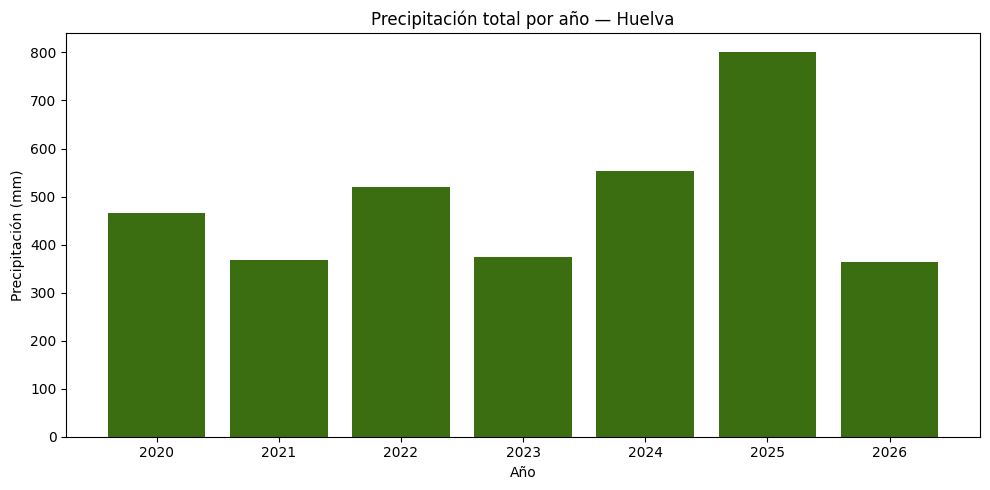

In [4]:
#Precipitación total por año
fig, ax = plt.subplots(figsize=(10, 5))
yearly_rain = df.groupby("year")["precipitation_sum"].sum()
ax.bar(yearly_rain.index.astype(str), yearly_rain.values, color="#3B6D11")
ax.set_title("Precipitación total por año — Huelva")
ax.set_xlabel("Año")
ax.set_ylabel("Precipitación (mm)")
plt.tight_layout()
plt.show()

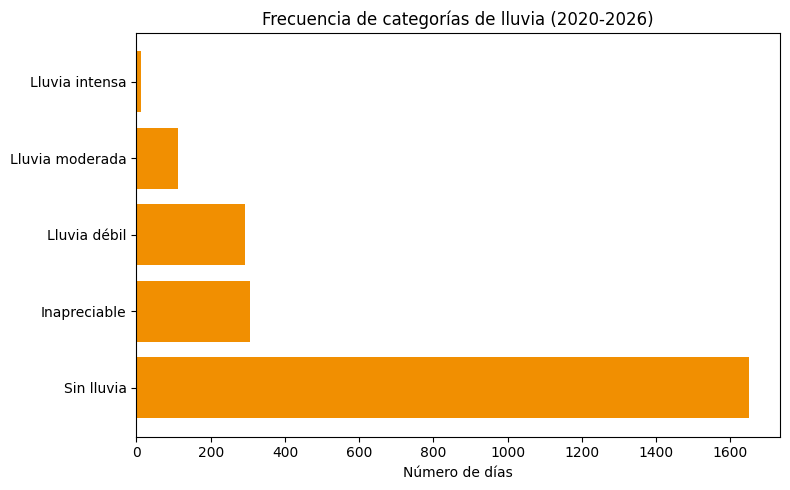

In [5]:
#Distribución categorías de lluvia
fig, ax = plt.subplots(figsize=(8, 5))
rain_counts = df["rain_category"].value_counts()
ax.barh(rain_counts.index, rain_counts.values, color="#F18F01")
ax.set_title("Frecuencia de categorías de lluvia (2020-2026)")
ax.set_xlabel("Número de días")
plt.tight_layout()
plt.show()

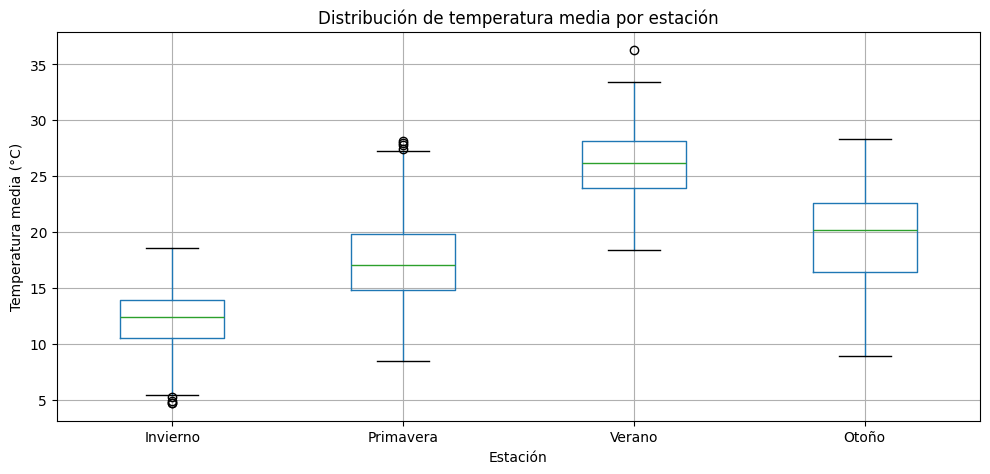

In [8]:
# Comparacion temparatura estación (boxplot)
# Convertimos 'season' a categoría ordenada para que el boxplot respete el orden
orden_estaciones = ["Invierno", "Primavera", "Verano", "Otoño"]
df["season"] = pd.Categorical(df["season"], categories=orden_estaciones, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column="temperature_2m_mean", by="season", ax=ax)
ax.set_title("Distribución de temperatura media por estación")
ax.set_xlabel("Estación")
ax.set_ylabel("Temperatura media (°C)")
plt.suptitle("")
plt.tight_layout()
plt.show()